<div dir="rtl">
# فصل ۶: یادگیری نظارت شده - رگرسیون خطی

## انواع رگرسیون خطی

در فصل قبل، یاد گرفتید که چگونه با استفاده از رگرسیون خطی ساده کار با یادگیری ماشین را شروع کنید، ابتدا با پایتون و سپس با کتابخانه Scikit-learn. در این فصل، به بررسی دقیق‌تر رگرسیون خطی می‌پردازیم و نوع دیگری از رگرسیون خطی به نام رگرسیون چندجمله‌ای را نیز بررسی می‌کنیم.

برای مرور، تصویر ۶.۱ مجموعه داده Iris را نشان می‌دهد که در فصل ۵ ("شروع کار با Scikit-learn برای یادگیری ماشین") استفاده شد. چهار ستون اول به عنوان ویژگی‌ها (یا متغیرهای مستقل) شناخته می‌شوند. ستون آخر به عنوان برچسب (یا متغیر وابسته) شناخته می‌شود.

image_placeholder.png

ویژگی‌ها گاهی متغیرهای توضیحی نیز نامیده می‌شوند، در حالی که برچسب‌ها گاهی اهداف نیز نامیده می‌شوند.

در رگرسیون خطی ساده، در مورد رابطه خطی بین یک متغیر مستقل و یک متغیر وابسته صحبت کردیم. در این فصل، علاوه بر رگرسیون خطی ساده، موارد زیر را نیز بررسی خواهیم کرد:

- **رگرسیون چندگانه (Multiple Regression)**: روابط خطی بین دو یا چند متغیر مستقل و یک متغیر وابسته.
- **رگرسیون چندجمله‌ای (Polynomial Regression)**: مدل‌سازی رابطه بین یک متغیر مستقل و یک متغیر وابسته با استفاده از یک تابع چندجمله‌ای درجه n.
- **رگرسیون چندجمله‌ای چندگانه (Polynomial Multiple Regression)**: مدل‌سازی رابطه بین دو یا چند متغیر مستقل و یک متغیر وابسته با استفاده از یک تابع چندجمله‌ای درجه n.

نکته: نوع دیگری از رگرسیون خطی به نام رگرسیون خطی چندمتغیره (multivariate linear regression) وجود دارد که در آن بیش از یک متغیر وابسته همبسته در رابطه وجود دارد. رگرسیون خطی چندمتغیره فراتر از scope این کتاب است.

## رگرسیون خطی

در یادگیری ماشین، رگرسیون خطی یکی از ساده‌ترین الگوریتم‌هایی است که می‌توانید روی یک مجموعه داده اعمال کنید تا روابط بین ویژگی‌ها و برچسب‌ها را مدل‌سازی کنید. در فصل ۵، با رگرسیون خطی ساده شروع کردیم، جایی که می‌توانستیم رابطه بین یک ویژگی و یک برچسب را با استفاده از یک خط راست توضیح دهیم. در بخش زیر، نوع دیگری از رگرسیون خطی ساده به نام رگرسیون خطی چندگانه را با پیش‌بینی قیمت خانه‌ها بر اساس چندین ویژگی یاد خواهید گرفت.
</div>

<div dir="rtl">

## استفاده از مجموعه داده Boston

برای این مثال، از مجموعه داده Boston استفاده می‌کنیم، که شامل داده‌های مربوط به مسکن و قیمت در منطقه بوستون است. این مجموعه داده از کتابخانه StatLib گرفته شده است که در دانشگاه Carnegie Mellon نگهداری می‌شود. این مجموعه داده به طور معمول در یادگیری ماشین استفاده می‌شود و گزینه مناسبی برای یادگیری مسائل رگرسیون است. مجموعه داده Boston از چندین منبع در دسترس است، اما اکنون به طور مستقیم از بسته `sklearn.datasets` در دسترس است. این به این معنی است که می‌توانید آن را مستقیماً در Scikit-learn بارگذاری کنید بدون اینکه نیاز به دانلود صریح آن داشته باشید.
</div>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import load_diabetes
import load_boston
dataset = load_boston.load_boston()


<div dir="rtl">
همیشه خوب است قبل از کار با داده، آن را بررسی کنید. ویژگی `data` حاوی داده‌های ستون‌های مختلف مجموعه داده است.
</div>

In [22]:
print(dataset.feature_names)


['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


<div dir="rtl">
برای توضیحات هر ویژگی، می‌توانید از ویژگی `DESCR` استفاده کنید.
</div>

In [23]:
print(dataset.DESCR)



Boston House Prices Dataset

**Data Set Characteristics:**

    :Number of Instances: 506

    :Number of Attributes: 13 numeric/categorical predictive

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by 

<div dir="rtl">
قیمت خانه‌ها اطلاعاتی است که ما به دنبال آن هستیم و می‌توان از طریق ویژگی `target` به آن دسترسی پیدا کرد.
</div>

In [24]:
print(dataset.target)


[24.  21.6 34.7 33.4 36.2 28.7 22.9 27.1 16.5 18.9 15.  18.9 21.7 20.4
 18.2 19.9 23.1 17.5 20.2 18.2 13.6 19.6 15.2 14.5 15.6 13.9 16.6 14.8
 18.4 21.  12.7 14.5 13.2 13.1 13.5 18.9 20.  21.  24.7 30.8 34.9 26.6
 25.3 24.7 21.2 19.3 20.  16.6 14.4 19.4 19.7 20.5 25.  23.4 18.9 35.4
 24.7 31.6 23.3 19.6 18.7 16.  22.2 25.  33.  23.5 19.4 22.  17.4 20.9
 24.2 21.7 22.8 23.4 24.1 21.4 20.  20.8 21.2 20.3 28.  23.9 24.8 22.9
 23.9 26.6 22.5 22.2 23.6 28.7 22.6 22.  22.9 25.  20.6 28.4 21.4 38.7
 43.8 33.2 27.5 26.5 18.6 19.3 20.1 19.5 19.5 20.4 19.8 19.4 21.7 22.8
 18.8 18.7 18.5 18.3 21.2 19.2 20.4 19.3 22.  20.3 20.5 17.3 18.8 21.4
 15.7 16.2 18.  14.3 19.2 19.6 23.  18.4 15.6 18.1 17.4 17.1 13.3 17.8
 14.  14.4 13.4 15.6 11.8 13.8 15.6 14.6 17.8 15.4 21.5 19.6 15.3 19.4
 17.  15.6 13.1 41.3 24.3 23.3 27.  50.  50.  50.  22.7 25.  50.  23.8
 23.8 22.3 17.4 19.1 23.1 23.6 22.6 29.4 23.2 24.6 29.9 37.2 39.8 36.2
 37.9 32.5 26.4 29.6 50.  32.  29.8 34.9 37.  30.5 36.4 31.1 29.1 50.
 33.3 3

<div dir="rtl">
حال بیایید داده‌ها را در یک DataFrame پانداس بارگذاری کنیم.
</div>

In [25]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head(7)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43


<div dir="rtl">
شما همچنین می‌خواهید قیمت خانه‌ها را نیز به DataFrame اضافه کنید، بنابراین بیایید یک ستون جدید به DataFrame اضافه کنیم و آن را `MEDV` بنامیم.
</div>

In [26]:
df['MEDV'] = dataset.target
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


<div dir="rtl">

## پاکسازی داده

مرحله بعدی پاکسازی داده و انجام هرگونه تبدیل در صورت لزوم است. ابتدا از تابع `info()` برای بررسی نوع داده هر فیلد استفاده کنید.
</div>

In [27]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


<div dir="rtl">

از آنجا که Scikit-learn فقط با فیلدهای عددی کار می‌کند، باید مقادیر رشته‌ای را به مقادیر عددی تبدیل کنید. خوشبختانه، مجموعه داده شامل تمام مقادیر عددی است، بنابراین هیچ رمزگذاری لازم نیست.

سپس، باید بررسی کنیم که آیا مقادیر 
خالی
وجود دارد یا خیر. برای انجام این کار، از تابع `isnull()` استفاده کنید.
</div>

In [28]:
print(df.isnull().sum())


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


<div dir="rtl">
باز هم، مجموعه داده خوب است، زیرا هیچ مقدار 
خالی
ندارد.

همبستگی مثبت (positive correlation) رابطه‌ای بین دو متغیر است که در آن هر دو متغیر با هم حرکت می‌کنند. یک همبستگی مثبت زمانی وجود دارد که یک متغیر کاهش می‌یابد و متغیر دیگر نیز کاهش می‌یابد، یا یک متغیر افزایش می‌یابد و متغیر دیگر نیز افزایش می‌یابد. به طور مشابه، همبستگی منفی (negative correlation) رابطه‌ای بین دو متغیر است که در آن یک متغیر با افزایش متغیر دیگر کاهش می‌یابد. یک همبستگی منفی کامل با مقدار `1.00-` نشان داده می‌شود: مقدار `0.00` نشان‌دهنده عدم همبستگی و `1.00+` نشان‌دهنده یک همبستگی مثبت کامل است.

از ستون `MEDV` در خروجی، می‌توانید ببینید که ویژگی‌های `RM` و `LSTAT` دارای عوامل همبستگی بالایی (همبستگی مثبت و منفی) با `MEDV` هستند.

این بدان معناست که با افزایش `LSTAT` ("درصد جمعیت با وضعیت پایین‌تر")، قیمت خانه‌ها کاهش می‌یابد. وقتی `LSTAT` کاهش می‌یابد، قیمت‌ها افزایش می‌یابد. به طور مشابه، با افزایش `RM` ("میانگین تعداد اتاق‌ها در هر واحد مسکونی")، قیمت نیز افزایش می‌یابد. و وقتی `RM` کاهش می‌یابد، قیمت‌ها نیز کاهش می‌یابند.

به جای یافتن بصری دو ویژگی برتر با بالاترین عوامل همبستگی، می‌توانیم این کار را به صورت برنامه‌نویسی به صورت زیر انجام دهیم.
</div>

In [29]:
corr = df.corr()
print(corr)


             CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
CRIM     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
ZN      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
INDUS    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
CHAS    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
NOX      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
RM      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
AGE      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
DIS     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
RAD      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
TAX      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
PTRATIO  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
B       -0.385064  0.175520 

In [30]:
#---get the top 3 features that has the highest correlation---
print(df.corr().abs().nlargest(3, 'MEDV').index)

#---print the top 3 correlation values---
print(df.corr().abs().nlargest(3, 'MEDV').values[:,13])


Index(['MEDV', 'LSTAT', 'RM'], dtype='str')
[1.         0.73766273 0.69535995]


<div dir="rtl">
از آنجا که `RM` و `LSTAT` مقادیر همبستگی بالایی دارند، از این دو ویژگی برای آموزش مدل خود استفاده خواهیم کرد.

## رگرسیون چندگانه

در فصل قبل، دیدید که چگونه می‌توان یک رگرسیون خطی ساده را با استفاده از یک ویژگی و یک برچسب انجام داد. اغلب، ممکن است بخواهید مدل خود را با استفاده از بیش از یک متغیر مستقل و یک برچسب آموزش دهید. این به عنوان رگرسیون چندگانه (multiple regression) شناخته می‌شود. در رگرسیون چندگانه، از دو یا چند متغیر مستقل برای پیش‌بینی مقدار یک متغیر وابسته (برچسب) استفاده می‌شود.

حال بیایید یک نمودار پراکندگی (scatter plot) نشان‌دهنده رابطه بین ویژگی `LSTAT` و برچسب `MEDV` رسم کنیم.
</div>

Text(0, 0.5, 'MEDV')

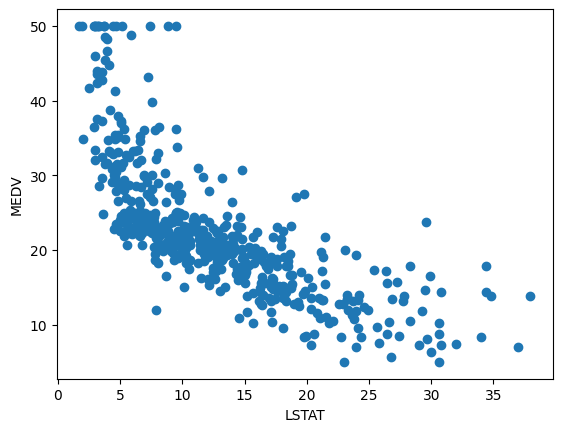

In [31]:
%matplotlib inline

plt.scatter(df['LSTAT'], df['MEDV'], marker='o')
plt.xlabel('LSTAT')
plt.ylabel('MEDV')


<div dir="rtl">
بیایید همچنین یک نمودار پراکندگی نشان‌دهنده رابطه بین ویژگی `RM` و برچسب `MEDV` رسم کنیم.
</div>

Text(0, 0.5, 'MEDV')

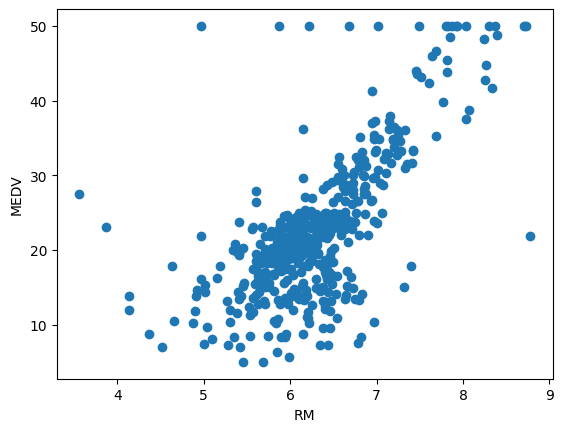

In [32]:
plt.scatter(df['RM'], df['MEDV'], marker='o')
plt.xlabel('RM')
plt.ylabel('MEDV')


<div dir="rtl">
بهتر از آن، بیایید دو ویژگی و برچسب را در یک نمودار سه بعدی رسم کنیم.
</div>

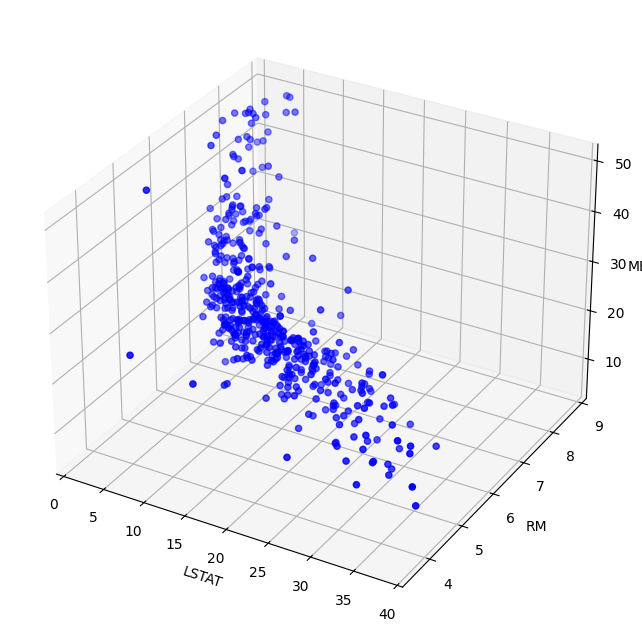

In [33]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['LSTAT'],
           df['RM'],
           df['MEDV'],
           c='b')

ax.set_xlabel("LSTAT")
ax.set_ylabel("RM")
ax.set_zlabel("MEDV")
plt.show()


<div dir="rtl">

## آموزش مدل

اکنون می‌توانیم مدل را آموزش دهیم. ابتدا دو DataFrame به نام‌های `x` و `Y` ایجاد کنید. DataFrame `x` شامل ترکیبی از ویژگی‌های `LSTAT` و `RM` خواهد بود، در حالی که DataFrame `Y` شامل برچسب `MEDV` خواهد بود.
</div>

In [34]:
x = pd.DataFrame(np.c_[df['LSTAT'], df['RM']], columns = ['LSTAT','RM'])
Y = df['MEDV']


<div dir="rtl">
مجموعه داده را به ۷۰ درصد برای آموزش و ۳۰ درصد برای آزمایش تقسیم می‌کنیم.

نکته: فصل ۷، "یادگیری نظارت شده - طبقه‌بندی با استفاده از رگرسیون لجستیک"، بیشتر در مورد تابع `train_test_split()` بحث خواهد کرد.
</div>

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size = 0.3,
                                                    random_state=5)


<div dir="rtl">
پس از تقسیم، بیایید شکل مجموعه‌های آموزش را چاپ کنیم.
</div>

In [36]:
print(x_train.shape)
print(Y_train.shape)


(354, 2)
(354,)


<div dir="rtl">
بیایید همچنین مجموعه آزمایش را چاپ کنیم.
</div>

In [37]:
print(x_test.shape)
print(Y_test.shape)


(152, 2)
(152,)


<div dir="rtl">
اکنون آماده شروع آموزش هستیم. همانطور که از فصل قبل یاد گرفتید، می‌توانید از کلاس `LinearRegression` برای انجام رگرسیون خطی استفاده کنید. در این مورد، از آن برای آموزش مدل خود استفاده خواهیم کرد.
</div>

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<div dir="rtl">
پس از آموزش مدل، از مجموعه آزمایش برای انجام چند پیش‌بینی استفاده می‌کنیم.
</div>

In [39]:
price_pred = model.predict(x_test)


<div dir="rtl">
برای فهمیدن اینکه مدل ما چقدر خوب عمل کرده است، از روش R- Squared استفاده می‌کنیم که در فصل قبل یاد گرفتید. روش R- Squared به شما می‌گوید که داده‌های آزمایش چقدر به خط رگرسیون نزدیک هستند. مقدار ۱.۰ به معنای برازش کامل است. بنابراین، هدف شما مقداری از R- Squared است که به ۱ نزدیک باشد.
</div>

In [40]:
print('R-squared: %.4f' % model.score(x_test,
                                      Y_test))


R-squared: 0.6162


<div dir="rtl">
همچنین یک نمودار پراکندگی نشان‌دهنده قیمت واقعی در مقابل قیمت پیش‌بینی شده رسم خواهیم کرد.
</div>

36.49422110915325


Text(0.5, 1.0, 'Actual prices vs Predicted prices')

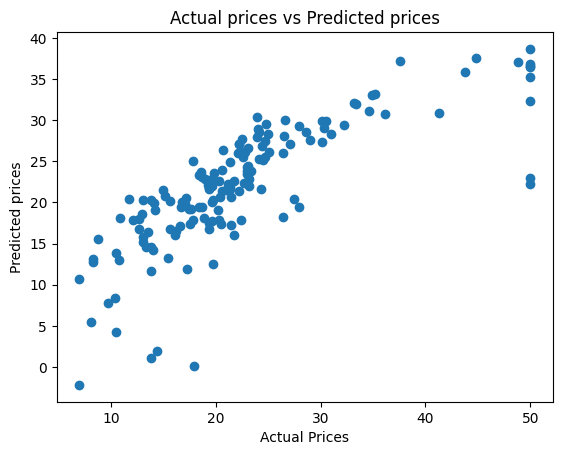

In [41]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, price_pred)
print(mse)

plt.scatter(Y_test, price_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted prices")
plt.title("Actual prices vs Predicted prices")


<div dir="rtl">

## دریافت عرض از مبدا و ضرایب

فرمول رگرسیون چندگانه به صورت زیر است:

Y = \beta_0 + \beta_1*x1 + \beta_2*x2

که در آن Y متغیر وابسته، \beta_0 عرض از مبدا (intercept) و \beta_1 و \beta_2 ضرایب دو ویژگی x1 و x2 هستند.

با آموزش مدل، می‌توانیم عرض از مبدا و همچنین ضرایب ویژگی‌ها را بدست آوریم.
</div>

In [42]:
print(model.intercept_)
print(model.coef_)


0.3843793678034473
[-0.65957972  4.83197581]


<div dir="rtl">
می‌توانیم از مدل برای پیش‌بینی قیمت خانه زمانی که `LSTAT` برابر ۳۰ و `RM` برابر ۵ است استفاده کنیم.
</div>

In [43]:
print(model.predict([[30,5]]))


[4.75686695]


d:\machine learning\ml_computer_b_1404_2\myvenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<div dir="rtl">
می‌توانید مقدار پیش‌بینی شده را با استفاده از فرمولی که قبلاً داده شد تأیید کنید.
</div>

<div dir="rtl">

## رسم ابرصفحه سه بعدی

بیایید یک ابرصفحه رگرسیون سه بعدی نشان‌دهنده پیش‌بینی‌ها رسم کنیم.
</div>

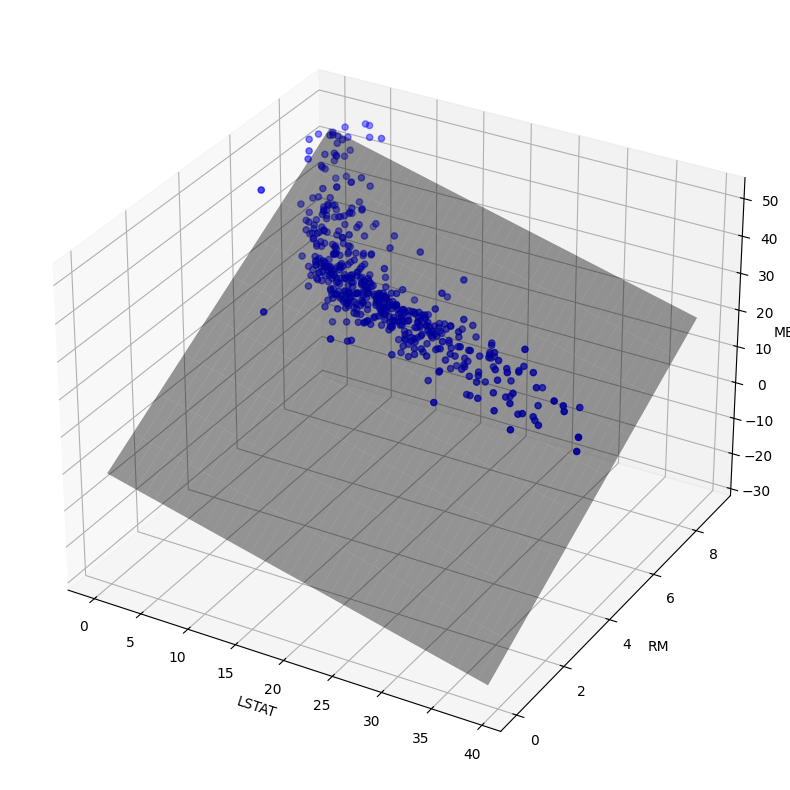

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import load_boston

# from sklearn.datasets import load_boston
dataset = load_boston.load_boston()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['MEDV'] = dataset.target

x = pd.DataFrame(np.c_[df['LSTAT'], df['RM']], columns = ['LSTAT','RM'])
Y = df['MEDV']

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x['LSTAT'],
           x['RM'],
           Y,
           c='b')

ax.set_xlabel("LSTAT")
ax.set_ylabel("RM")
ax.set_zlabel("MEDV")

#---create a meshgrid of all the values for LSTAT and RM---
x_surf = np.arange(0, 40, 1)   #---for LSTAT---
y_surf = np.arange(0, 10, 1)   #---for RM---
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, Y)

#---calculate z(MEDC) based on the model---
z = lambda x,y: (model.intercept_ + model.coef_[0] * x + model.coef_[1] * y)

ax.plot_surface(x_surf, y_surf, z(x_surf,y_surf),
                rstride=1,
                cstride=1,
                color='None',
                alpha = 0.4)

plt.show()


<div dir="rtl">

موارد بالا را در یک فایل پایتون امتحان کنید.
</div>

<div dir="rtl">

## رگرسیون چندجمله‌ای

در بخش قبلی، دیدید که چگونه می‌توان رگرسیون خطی را برای پیش‌بینی قیمت خانه‌ها در منطقه بوستون اعمال کرد. اگرچه نتیجه تا حدی قابل قبول است، اما بسیار دقیق نیست. این به این دلیل است که گاهی اوقات یک خط رگرسیون خطی ممکن است بهترین راه حل برای ضبط دقیق روابط بین ویژگی‌ها و برچسب نباشد. در برخی موارد، یک خط منحنی ممکن است بهتر عمل کند.

مجموعه نقاط نشان داده شده در تصویر ۶.۱۰ را در نظر بگیرید.

مجموعه نقاط در یک فایل به نام `polynomial.csv` ذخیره شده است.
</div>

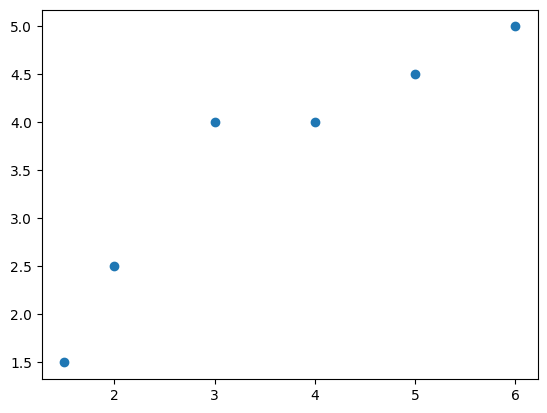

In [47]:
df = pd.read_csv('polynomial.csv')
plt.scatter(df.x,df.y)


<div dir="rtl">
با استفاده از رگرسیون خطی، می‌توانید سعی کنید یک خط راست رسم کنید که از بیشتر نقاط عبور کند.
</div>

In [ ]:
model = LinearRegression()

x = df.x[0:6].to_numpy().reshape(-1,1)   #---convert to 2D array---
y = df.y[0:6].to_numpy().reshape(-1,1)    #---convert to 2D array---

model.fit(x,y)

#---perform prediction---
y_pred = model.predict(x)

#---plot the training points---
plt.scatter(x, y, s=10, color='b')

#---plot the straight line---
plt.plot(x, y_pred, color='r')
plt.show()

#---calculate R-squared---
print('R-squared for training set: %.4f' % model.score(x,y))


<div dir="rtl">
ما می‌خواهیم ببینیم آیا راه دقیق‌تری برای برازش نقاط وجود دارد. برای مثال، به جای یک خط راست، می‌خواهیم امکان یک خط منحنی را بررسی کنیم. اینجاست که رگرسیون چندجمله‌ای مطرح می‌شود.

## فرمول رگرسیون چندجمله‌ای

رگرسیون چندجمله‌ای تلاشی برای ایجاد یک تابع چندجمله‌ای است که با مجموعه‌ای از نقاط داده برازش می‌شود.

یک تابع چندجمله‌ای درجه ۱ به شکل زیر است:

Y = \beta_0 + \beta_1*x

این همان رگرسیون خطی ساده است که در فصل قبل دیدیم. رگرسیون درجه ۲ (quadratic regression) یک چندجمله‌ای درجه ۲ است:

Y = \beta_0 + beta1*x + beta2*x^2

برای یک چندجمله‌ای درجه ۳، فرمول به صورت زیر است:

Y = beta0 + beta1*x + beta2*x^2 + beta3*x^3

به طور کلی، یک چندجمله‌ای درجه n دارای فرمول زیر است:

Y = beta0 + beta1*x + beta2*x^2 + beta3*x^3 + ... + beta_n*x^n

ایده پشت رگرسیون چندجمله‌ای ساده است — یافتن ضرایب تابع چندجمله‌ای که بهترین برازش را با داده‌ها دارد.

## رگرسیون چندجمله‌ای در Scikit-learn

کتابخانه Scikit-learn شامل تعدادی کلاس و تابع برای حل رگرسیون چندجمله‌ای است. کلاس `PolynomialFeatures` یک عدد را به عنوان ورودی می‌گیرد که درجه ویژگی‌های چندجمله‌ای را مشخص می‌کند. در قطعه کد زیر، ما یک معادله درجه ۲ (تابع چندجمله‌ای درجه ۲) ایجاد می‌کنیم.
</div>

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
degree = 2

polynomial_features = PolynomialFeatures(degree = degree)


<div dir="rtl">
با استفاده از این شیء `PolynomialFeatures`، می‌توانید یک ماتریس ویژگی جدید متشکل از تمام ترکیبات چندجمله‌ای ویژگی‌ها با درجه کمتر یا مساوی درجه مشخص شده تولید کنید.
</div>

In [ ]:
x_poly = polynomial_features.fit_transform(x)
print(x_poly)


<div dir="rtl">
ماتریسی که می‌بینید به صورت زیر تولید می‌شود:
- ستون اول همیشه ۱ است.
- ستون دوم مقدار x است.
- ستون سوم مقدار x^2 است.

این را می‌توان با استفاده از تابع `get_feature_names()` تأیید کرد.

نکته: ریاضیات پشت یافتن ضرایب یک تابع چندجمله‌ای فراتر از scope این کتاب است. با این حال، برای کسانی که علاقه‌مند هستند، لینک زیر را در مورد ریاضیات پشت رگرسیون چندجمله‌ای بررسی کنید: `http://polynomialregression.drque.net/math.html`.

اکنون از این ماتریس تولید شده با کلاس `LinearRegression` برای آموزش مدل خود استفاده خواهید کرد.
</div>

In [ ]:
model = LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)

#---plot the points---
plt.scatter(x, y, s=10)

#---plot the regression line---
plt.plot(x, y_poly_pred)
plt.show()


<div dir="rtl">
می‌توانید عرض از مبدا و ضرایب تابع چندجمله‌ای را چاپ کنید.
</div>

In [ ]:
print(model.intercept_)
print(model.coef_)


<div dir="rtl">
با قرار دادن این اعداد در فرمول Y = beta0 + beta1*x + beta2*x^2، می‌توانید با استفاده از فرمول فوق پیش‌بینی‌هایی انجام دهید.

اگر رگرسیون را با چاپ مقدار R- Squared آن ارزیابی کنید.
</div>

In [ ]:
print('R-squared for training set: %.4f' % model.score(x_poly,y))


<div dir="rtl">
آیا می‌توان مقدار R- Squared را بهبود بخشید؟ بیایید یک چندجمله‌ای درجه ۳ را امتحان کنیم. با استفاده از کد مشابه و تغییر `degree` به ۳، باید منحنی و مقدار ۰.۹۸۸۹ را برای R- Squared دریافت کنید.

اکنون منحنی را می‌بینید که نقاط را دقیق‌تر برازش می‌کند و مقدار R- Squared بسیار بهبود یافته است. علاوه بر این، از آنجا که افزایش درجه چندجمله‌ای به میزان ۱ مقدار R- Squared را بهبود می‌بخشد، ممکن است وسوسه شوید که آن را بیشتر افزایش دهید. در واقع، تصویر ۶.۱۴ منحنی را نشان می‌دهد که درجه به ۴ تنظیم شده است. این منحنی به طور کامل با تمام نقاط برازش می‌شود.

و حدس بزنید چه؟ مقدار R- Squared برابر ۱ می‌شود! با این حال، قبل از اینکه موفقیت خود را در یافتن الگوریتم کامل در پیش‌بینی خود جشن بگیرید، باید بدانید که در حالی که الگوریتم شما ممکن است داده‌های آموزش را به طور کامل برازش کند، احتمالاً با داده‌های جدید خوب عمل نخواهد کرد. این به عنوان overfitting شناخته می‌شود و بخش بعدی این موضوع را با جزئیات بیشتری بحث خواهد کرد.

## درک بایاس و واریانس

ناتوانی یک الگوریتم یادگیری ماشین در تشخیص رابطه واقعی بین متغیرها و خروجی به عنوان بایاس (bias) شناخته می‌شود. تصویر ۶.۱۵ یک خط راست را نشان می‌دهد که سعی می‌کند با تمام نقاط برازش شود. از آنجا که از تمام نقاط عبور نمی‌کند، بایاس بالایی دارد.

</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="bias1.png" width="700" height="450">
</div>
 </div>
  </div>



<div dir="rtl">
با این حال، خط منحنی در تصویر ۶.۱۶ قادر است با تمام نقاط برازش شود و بنابراین بایاس پایینی دارد.
</div>
 



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="bias2.png" width="700" height="450">
</div>



<div dir="rtl">

در حالی که خط راست نمی‌تواند از تمام نقاط عبور کند و بایاس بالایی دارد، زمانی که نوبت به اعمال مشاهدات دیده نشده می‌رسد، تخمین نسبتاً خوبی می‌دهد. تصویر ۶.۱۷ نقاط آزمایش (به رنگ صورتی) را نشان می‌دهد. RSS (مجموع مربعات باقیمانده‌ها)، که مجموع خطاهای پیش‌بینی است، در مقایسه با خط منحنی هنگام استفاده از همان نقاط آزمایش، بسیار پایین است.


</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="var1.png" width="500" height="280">
  <img src="var2.png" width="500" height="280">
</div>
</div>
</div>


<div dir="rtl">

در یادگیری ماشین، برازش بین مجموعه‌های داده به عنوان واریانس (variance) شناخته می‌شود. در این مثال، خط منحنی واریانس بالایی دارد زیرا منجر به RSS بسیار متفاوت برای مجموعه داده‌های مختلف می‌شود. به عبارت دیگر، شما واقعاً نمی‌توانید پیش‌بینی کنید که با مجموعه داده‌های آینده چقدر خوب عمل خواهد کرد - گاهی اوقات با مجموعه داده‌های خاصی خوب عمل می‌کند و در مواقع دیگر ممکن است به شدت شکست بخورد. از طرف دیگر، خط راست واریانس پایینی دارد، زیرا RSS برای مجموعه داده‌های مختلف مشابه است.

نکته: در یادگیری ماشین، زمانی که سعی می‌کنیم منحنی را پیدا کنیم که سعی می‌کند با تمام نقاط به طور کامل برازش شود، به عنوان overfitting شناخته می‌شود. از طرف دیگر، اگر خطی داشته باشیم که با اکثر نقاط برازش نمی‌شود، به عنوان underfitting شناخته می‌شود.

در حالت ایده‌آل، باید خطی پیدا کنیم که به طور دقیق روابط بین متغیرهای مستقل و نتیجه را بیان کند. که بر حسب بایاس و واریانس بیان می‌شود، الگوریتم ایده‌آل باید دارای ویژگی‌های زیر باشد:

- بایاس پایین، با خطی که تا حد امکان به نقاط زیادی می‌چسبد.
- واریانس پایین، با خطی که منجر به پیش‌بینی‌های ثابت با استفاده از مجموعه داده‌های مختلف می‌شود.

تصویر ۶.۱۹ چنین منحنی ایده‌آلی را نشان می‌دهد - بایاس بالا و واریانس پایین.

</div>




</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="bias_var.png" width="700" height="450">
</div>




<div dir="rtl">
برای ایجاد تعادل بین یافتن یک مدل ساده و یک مدل پیچیده، می‌توانید از تکنیک‌هایی مانند Regularization، Bagging و Boosting استفاده کنید:

- Regularization تکنیکی است که به طور خودکار ویژگی‌های اضافی را که در مدل‌سازی خود استفاده کرده‌اید، جریمه می‌کند.
- Bagging (یا bootstrap aggregation) یک نوع خاص از فرآیند یادگیری ماشین است که از یادگیری ensemble برای تکامل مدل‌های یادگیری ماشین استفاده می‌کند. Bagging از زیرمجموعه‌ای از داده‌ها استفاده می‌کند و هر نمونه یک یادگیرنده ضعیف‌تر را آموزش می‌دهد. سپس یادگیرنده‌های ضعیف می‌توانند (از طریق میانگین‌گیری یا حداکثر رای) ترکیب شوند تا یک یادگیرنده قوی ایجاد کنند که می‌تواند پیش‌بینی‌های دقیقی انجام دهد.
- Boosting نیز مشابه Bagging است، با این تفاوت که از تمام داده‌ها برای آموزش هر یادگیرنده استفاده می‌کند، اما نقاط داده‌ای که توسط یادگیرندگان قبلی به اشتباه طبقه‌بندی شده‌اند، وزن بیشتری به آنها داده می‌شود تا یادگیرندگان بعدی در طول آموزش توجه بیشتری به آنها داشته باشند.

نکته: یادگیری Ensemble تکنیکی است که در آن از چندین مدل استفاده می‌کنید که با هم روی یک مجموعه داده واحد کار می‌کنند و سپس نتیجه آن را ترکیب می‌کنید.

</div>

<div dir="rtl">

## استفاده از رگرسیون چندجمله‌ای چندگانه در مجموعه داده Boston

قبلاً در این فصل، از رگرسیون خطی چندگانه استفاده کردید و مدلی را بر اساس مجموعه داده Boston آموزش دادید. پس از یادگیری در مورد رگرسیون چندجمله‌ای در بخش قبل، حالا بیایید سعی کنیم آن را در مجموعه داده Boston اعمال کنیم و ببینیم آیا می‌توانیم مدل را بهبود بخشیم.

طبق معمول، بیایید داده‌ها را بارگذاری کنیم و مجموعه داده را به مجموعه‌های آموزش و آزمایش تقسیم کنیم.
</div>

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import load_boston

dataset = load_boston.load_boston()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['MEDV'] = dataset.target

x = pd.DataFrame(np.c_[df['LSTAT'], df['RM']], columns = ['LSTAT','RM'])
Y = df['MEDV']

from sklearn.model_selection import train_test_split
x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size = 0.3,
                                                    random_state=5)


<div dir="rtl">
سپس از تابع چندجمله‌ای با درجه ۲ استفاده می‌کنید.

هنگام استفاده از یک تابع چندجمله‌ای درجه ۲ روی دو متغیر مستقل x1 و x2، فرمول به صورت زیر می‌شود:
</div>
<div>

$$Y = \beta_0 + \beta_1*x_1 + \beta_2*x_2 + \beta_3*x_1^2 + \beta_4*x_1*x_2 + \beta_5*x_2^2$$

</div>
<div dir="rtl">

که در آن 
Y 
متغیر وابسته، 
beta0
عرض از مبدا و beta1, beta2, beta3, beta4 ضرایب ترکیبات مختلف دو ویژگی x1 و x2 هستند. می‌توانید این را با چاپ نام ویژگی‌ها تأیید کنید.

نکته: دانستن فرمول تابع چندجمله‌ای هنگام رسم ابرصفحه سه بعدی مفید است، که به زودی انجام خواهید داد.

سپس می‌توانید مدل خود را با استفاده از کلاس `LinearRegression` آموزش دهید.
</div>

In [48]:
#---use a polynomial function of degree 2---
degree = 2
polynomial_features= PolynomialFeatures(degree = degree)
x_train_poly = polynomial_features.fit_transform(x_train)
print(x_train_poly)


[[  1.        23.98       6.459    575.0404   154.88682   41.718681]
 [  1.        21.52       6.193    463.1104   133.27336   38.353249]
 [  1.         7.74       6.75      59.9076    52.245     45.5625  ]
 ...
 [  1.        17.6        5.67     309.76      99.792     32.1489  ]
 [  1.        10.97       6.326    120.3409    69.39622   40.018276]
 [  1.         5.57       5.936     31.0249    33.06352   35.236096]]


In [49]:
#---print out the formula---
print(polynomial_features.get_feature_names_out())


['1' 'LSTAT' 'RM' 'LSTAT^2' 'LSTAT RM' 'RM^2']


In [50]:
model = LinearRegression()
model.fit(x_train_poly, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<div dir="rtl">
حال بیایید مدل را با استفاده از مجموعه آزمایش ارزیابی کنیم.
</div>

In [51]:
x_test_poly = polynomial_features.fit_transform(x_test)
print('R-squared: %.4f' % model.score(x_test_poly,
                                      Y_test))


R-squared: 0.7340


<div dir="rtl">
همچنین می‌توانید عرض از مبدا و ضرایب را چاپ کنید.
</div>

In [52]:
print(model.intercept_)
print(model.coef_)


26.933430523839384
[ 0.00000000e+00  1.47424550e+00 -6.70204730e+00  7.93570743e-04
 -3.66578385e-01  1.17188007e+00]


<div dir="rtl">
با این مقادیر، فرمول اکنون به صورت زیر می‌شود:
</div>
<div>

$$Y = \beta_0 + \beta_1*x_1 + \beta_2*x_2 + \beta_3*x_1^2 + \beta_4*x_1*x_2 + \beta_5*x_2^2$$

</div>
<div dir="rtl">


## رسم ابرصفحه سه بعدی

از آنجا که عرض از مبدا و ضرایب تابع رگرسیون چندجمله‌ای چندگانه را می‌دانید، می‌توانید به راحتی ابرصفحه سه بعدی تابع را رسم کنید. قطعه کد زیر را به عنوان یک فایل به نام `boston2.py` ذخیره کنید.
</div>

['1' 'LSTAT' 'RM' 'LSTAT^2' 'LSTAT RM' 'RM^2']


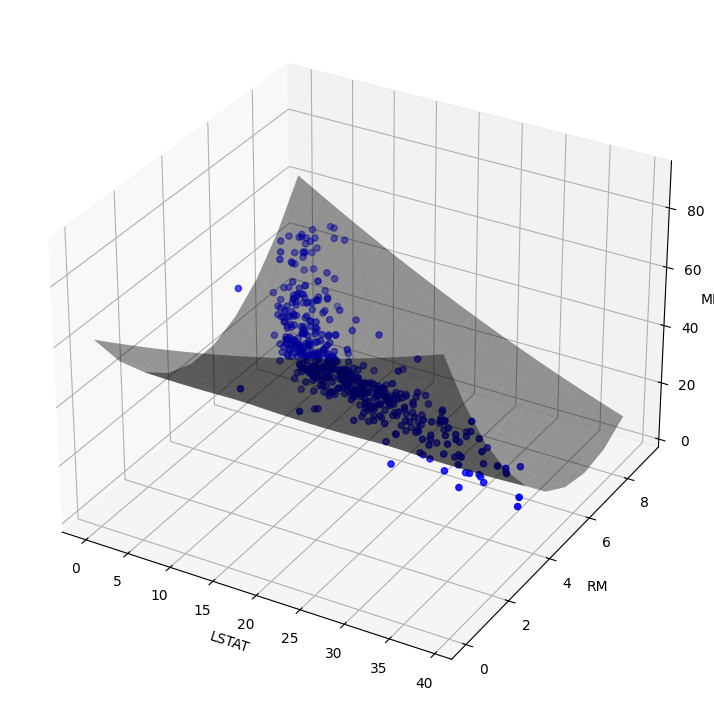

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import load_boston

dataset = load_boston.load_boston()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['MEDV'] = dataset.target

x = pd.DataFrame(np.c_[df['LSTAT'], df['RM']], columns = ['LSTAT','RM'])
Y = df['MEDV']

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x['LSTAT'],
           x['RM'],
           Y,
           c='b')

ax.set_xlabel("LSTAT")
ax.set_ylabel("RM")
ax.set_zlabel("MEDV")

#---create a meshgrid of all the values for LSTAT and RM---
x_surf = np.arange(0, 40, 1)   #---for LSTAT---
y_surf = np.arange(0, 10, 1)   #---for RM---
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

#---use a polynomial function of degree 2---
degree = 2
polynomial_features= PolynomialFeatures(degree = degree)
x_poly = polynomial_features.fit_transform(x)
print(polynomial_features.get_feature_names_out())

#---apply linear regression---
model = LinearRegression()
model.fit(x_poly, Y)

#---calculate z(MEDC) based on the model---
z = lambda x,y: (model.intercept_ +
                (model.coef_[1] * x) +
                (model.coef_[2] * y) +
                (model.coef_[3] * x**2) +
                (model.coef_[4] * x*y) +
                (model.coef_[5] * y**2))

ax.plot_surface(x_surf, y_surf, z(x_surf,y_surf),
                rstride=1,
                cstride=1,
                color='None',
                alpha = 0.4)

plt.show()
